MINE



In [771]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, classification_report, accuracy_score
from sklearn.decomposition import PCA
from scipy import stats
import plotly.express as px
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

In [772]:


# Load the dataset
df = pd.read_excel("amazon.xlsx")  # or the exact path to your file
df.dropna(how='all', inplace=True)  # Remove completely empty rows


In [773]:
# Clean column names
df.columns = df.columns.str.strip()


In [774]:
# Data Cleaning (Based on Problem Statement)
# -------------------

# 1. Handle Missing Values
print("\nMissing Values Summary Before Cleaning:\n", df.isnull().sum())

num_cols = ['Age', 'Purchase Amount', 'Rating']
cat_cols = ['Payment Method']

for col in num_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    if col in df.columns:
        df[col].fillna(df[col].mode()[0], inplace=True)



Missing Values Summary Before Cleaning:
 Customer_ID                     0
Customer_Name                  77
Age                             0
Gender                          0
Location                        0
Product_Category                0
Product_ID                      0
Purchase_Date                   0
Purchase_Amount                 0
Payment_Method                  0
Rating                          0
Feedback_Comments             709
Customer_Lifetime_Value         0
Loyalty_Score                   0
Discount_Applied                0
Return_Status                   0
Customer_Segment                0
Preferred_Shopping_Channel      0
Churn                           0
dtype: int64


In [775]:
# 2. Remove Duplicates
if 'Customer ID' in df.columns and 'Purchase Date' in df.columns:
    df.drop_duplicates(subset=['Customer ID', 'Purchase Date'], inplace=True)


In [776]:
# 3. Format Dates
if 'Purchase Date' in df.columns:
    df['Purchase Date'] = pd.to_datetime(df['Purchase Date'], errors='coerce')


In [777]:
# 4. Standardise Categorical Values
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].str.strip().str.title()


In [778]:
# 5. Ensure Consistent Data Types
label_cols = ['Gender', 'Payment Method', 'Preferred Shopping Channel']
le = LabelEncoder()
for col in label_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))


In [779]:
# 6. Convert Yes/No fields to binary
binary_map = {'Yes': 1, 'No': 0}
if 'Discount Applied' in df.columns:
    df['Discount Applied'] = df['Discount Applied'].map(binary_map)
if 'Return Status' in df.columns:
    df['Return Status'] = df['Return Status'].map(binary_map)

# 7. Handle Outliers (Z-score)
for col in ['Purchase Amount']:
    if col in df.columns:
        df = df[np.abs(stats.zscore(df[col])) < 3]

In [780]:
print(df.head())

   Customer_ID Customer_Name  Age  Gender       Location Product_Category  \
0        10860           Eve   33       2        Houston  Home Appliances   
1        15191           Eve   66       2  San Francisco      Electronics   
2        15734           Eve   38       0       New York             Toys   
3        16265           Bob   26       2       New York         Clothing   
4        10466       Charlie   23       0       New York         Clothing   

   Product_ID       Purchase_Date  Purchase_Amount Payment_Method  Rating  \
0         393 2020-01-01 01:00:00       144.326722           Cash       5   
1         405 2020-01-01 03:00:00       226.655516  Bank Transfer       2   
2         353 2020-01-01 04:00:00        37.851880  Bank Transfer       2   
3         279 2020-01-01 05:00:00       489.462288         PayPal       3   
4         139 2020-01-01 06:00:00       298.332443         PayPal       4   

  Feedback_Comments  Customer_Lifetime_Value  Loyalty_Score  Discount_Appl

In [781]:
# --- Feature Engineering ---
from datetime import datetime

df.rename(columns={
    'Purchase Amount': 'Purchase_Amount',
    'Customer ID': 'Customer_ID',
    'Discount Applied': 'Discount_Applied'
}, inplace=True)

# 1. Calculate total spend and order count per customer
if 'Customer_ID' in df.columns and 'Purchase_Amount' in df.columns:
    agg_data = df.groupby('Customer_ID').agg({
        'Purchase_Amount': ['sum', 'count']
    }).reset_index()
    agg_data.columns = ['Customer_ID', 'Total_Spend', 'Order_Count']
    agg_data['Avg_Purchase'] = agg_data['Total_Spend'] / agg_data['Order_Count']

    # 2. Estimate CLV = Avg Purchase × Order Count
    agg_data['CLV'] = agg_data['Avg_Purchase'] * agg_data['Order_Count']

    # 3. Loyalty Score = Total Spend × Order Count
    agg_data['Loyalty_Score'] = agg_data['Total_Spend'] * agg_data['Order_Count']

    # 4. Merge — guard prevents _x/_y suffixes if cell is re-run
    # ✅ Replace with this
    if 'CLV' not in df.columns:
        # NEW — merge only CLV (Loyalty_Score already exists in df from raw data)
       cols_to_merge = ['Customer_ID', 'CLV']
       df = pd.merge(df, agg_data[cols_to_merge], on='Customer_ID', how='left')
    else:
        print("ℹ️ CLV already exists — skipping merge to prevent duplicate columns.")
   # Safety cleanup — drop any _x/_y duplicates from accidental re-runs
    for col in ['CLV', 'Loyalty_Score', 'Purchase_Frequency', 'Avg_Purchase_Value', 'Days_Since_Purchase']:
        if f'{col}_x' in df.columns:
            df.rename(columns={f'{col}_x': col}, inplace=True)
        if f'{col}_y' in df.columns and col != 'Loyalty_Score':
            df.drop(columns=[f'{col}_y'], inplace=True)
    if 'Loyalty_Score_x' in df.columns:
        df.drop(columns=['Loyalty_Score_x'], inplace=True)

else:
    print("Warning: 'Customer_ID' or 'Purchase_Amount' not found. CLV and Loyalty Score not calculated.")


# 5. Purchase Frequency, Avg Purchase Value, Days Since Last Purchase
if 'Customer_ID' in df.columns and 'Purchase_Date' in df.columns and 'Purchase_Amount' in df.columns:
    grouped = df.groupby('Customer_ID')

    purchase_freq = grouped['Purchase_Date'].count().rename("Purchase_Frequency")
    avg_purchase_value = grouped['Purchase_Amount'].mean().rename("Avg_Purchase_Value")

    if pd.api.types.is_datetime64_any_dtype(df['Purchase_Date']):
        days_since_last = (datetime.now() - grouped['Purchase_Date'].max()).dt.days.rename("Days_Since_Purchase")
    else:
        print("Warning: 'Purchase_Date' is not datetime type. 'Days_Since_Purchase' not calculated.")
        days_since_last = pd.Series(np.nan, index=grouped.indices.keys()).rename("Days_Since_Purchase")

    # Guard: skip merge if these columns already exist (prevents _x/_y on re-run)
    if 'Purchase_Frequency' not in df.columns:
        df_features_new = pd.concat([purchase_freq, avg_purchase_value, days_since_last], axis=1).reset_index()
        df = pd.merge(df, df_features_new, on='Customer_ID', how='left')
    else:
        print("ℹ️ Purchase features already exist — skipping merge.")

else:
    print("Warning: Required columns not found. Skipping purchase feature calculation.")

# Confirm
print("\nDataFrame columns after Feature Engineering:\n", df.columns.tolist())
print("Does df contain 'CLV'?", 'CLV' in df.columns)
print("Does df contain 'Loyalty_Score'?", 'Loyalty_Score' in df.columns)



DataFrame columns after Feature Engineering:
 ['Customer_ID', 'Customer_Name', 'Age', 'Gender', 'Location', 'Product_Category', 'Product_ID', 'Purchase_Date', 'Purchase_Amount', 'Payment_Method', 'Rating', 'Feedback_Comments', 'Customer_Lifetime_Value', 'Loyalty_Score', 'Discount_Applied', 'Return_Status', 'Customer_Segment', 'Preferred_Shopping_Channel', 'Churn', 'CLV', 'Purchase_Frequency', 'Avg_Purchase_Value', 'Days_Since_Purchase']
Does df contain 'CLV'? True
Does df contain 'Loyalty_Score'? True


In [782]:
print("--- Debug after Final Feature Engineering Block ---")
print("Current DataFrame columns:", df.columns.tolist())
print("Is 'CLV' in columns?", 'CLV' in df.columns)
print("Is 'Loyalty_Score_y' in columns?", 'Loyalty_Score_y' in df.columns)
print("Is 'Churn' in columns?", 'Churn' in df.columns) # Check if Churn is already there
print("--- End Debug ---")

--- Debug after Final Feature Engineering Block ---
Current DataFrame columns: ['Customer_ID', 'Customer_Name', 'Age', 'Gender', 'Location', 'Product_Category', 'Product_ID', 'Purchase_Date', 'Purchase_Amount', 'Payment_Method', 'Rating', 'Feedback_Comments', 'Customer_Lifetime_Value', 'Loyalty_Score', 'Discount_Applied', 'Return_Status', 'Customer_Segment', 'Preferred_Shopping_Channel', 'Churn', 'CLV', 'Purchase_Frequency', 'Avg_Purchase_Value', 'Days_Since_Purchase']
Is 'CLV' in columns? True
Is 'Loyalty_Score_y' in columns? False
Is 'Churn' in columns? True
--- End Debug ---


✅ Real Churn column loaded (already numeric).
Churn distribution:
Churn
1    797
0    794
Name: count, dtype: int64
Churn rate: 50.09%
Info: Re-encoded 'Payment_Method' (Payment_Method) to numeric within churn block.
After SMOTE — class distribution: {np.int64(0): np.int64(637), np.int64(1): np.int64(637)}

Distribution of Synthetic Churn in Test Set (y_test_churn):
Churn
1    160
0    159
Name: count, dtype: int64

📊 Churn Prediction Metrics:
✅ Accuracy: 83.07%
✅ Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.84       159
           1       0.85      0.80      0.83       160

    accuracy                           0.83       319
   macro avg       0.83      0.83      0.83       319
weighted avg       0.83      0.83      0.83       319


✅ Confusion Matrix:
 [[137  22]
 [ 32 128]]


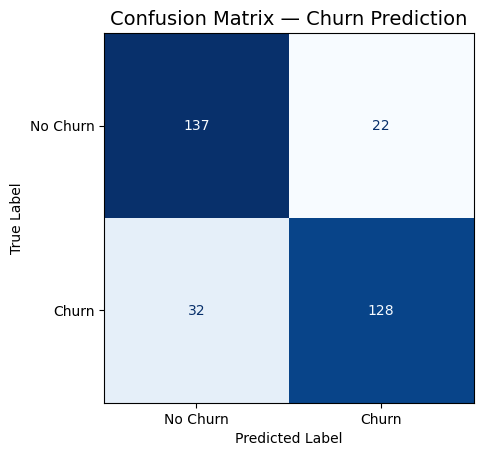

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder # Ensure LabelEncoder is imported
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib # Ensure joblib is imported for model saving

# Assuming 'df' DataFrame is already loaded and preprocessed as per previous steps.

# --- Synthetic Churn Column Creation ---
# Business logic: if CLV < 25th percentile and Loyalty_Score < 25th percentile → churn
# It is already binary int64 (0/1) — no synthetic override needed.
if 'Churn' not in df.columns:
    print("Error: 'Churn' column not found in dataset. Cannot proceed.")
    df['Churn'] = np.nan
elif df['Churn'].dtype == 'object':
    # Handle string-encoded churn (e.g., 'Yes'/'No')
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    print(f"Churn distribution:\n{df['Churn'].value_counts()}")
    print(f"Churn rate: {df['Churn'].mean():.2%}")
else:
    # Already numeric (int64) — just confirm it's healthy
    print(f"✅ Real Churn column loaded (already numeric).")
    print(f"Churn distribution:\n{df['Churn'].value_counts()}")
    print(f"Churn rate: {df['Churn'].mean():.2%}")


# --- Churn Prediction (Logistic Regression) ---

# Define desired features - CORRECTED to use 'CLV' instead of 'CLV_y'
desired_churn_features = ['Age', 'Purchase_Amount', 'Discount_Applied', 'Payment_Method', 'Loyalty_Score', 'CLV', 'Purchase_Frequency', 'Days_Since_Purchase']
actual_churn_features = []

# Build a list of features that actually exist in the DataFrame
for col in desired_churn_features:
    if col in df.columns:
        actual_churn_features.append(col)
    else:
        print(f"Warning: Churn feature '{col}' not found. It will be excluded from the model.")

# Ensure 'Churn' target column is numeric (0 or 1) and has no NaNs
if 'Churn' in df.columns:
    df['Churn'] = pd.to_numeric(df['Churn'], errors='coerce')
    # Robustly fill NaNs in target: check if mode() returns an empty Series
    if not df['Churn'].mode().empty:
        df['Churn'].fillna(df['Churn'].mode()[0], inplace=True)
    else:
        # If mode is empty (all NaNs), fill with a default like 0 (no churn) or raise error
        df['Churn'].fillna(0, inplace=True) # Default to 0 if all NaNs
        print("Warning: 'Churn' column was all NaNs and filled with 0 for prediction.")
else:
    print("Error: 'Churn' target column not found. Cannot proceed with Churn prediction.")
    # This error should ideally stop execution if 'Churn' is critical
    df['Churn'] = np.nan # Ensure 'Churn' exists, even if NaN, to prevent later errors


# --- Robust Numerical Conversion for Churn Features ---
# This section ensures that all features in actual_churn_features are numeric
# before being passed to the StandardScaler, handling cases where previous
# encoding steps might not have fully propagated or if this block is run in isolation.
for col in actual_churn_features:
    if col in df.columns: # Double check column existence
        if df[col].dtype == 'object':
            if col == 'Payment_Method':
                # Re-apply Label Encoding for Payment_Method if it's still an object
    
                # Ensure all values are strings before fitting/transforming
                df[col] = le_pm.fit_transform(df[col].astype(str))
                print(f"Info: Re-encoded '{col}' (Payment_Method) to numeric within churn block.")
            elif col == 'Discount_Applied':
                # Re-apply binary mapping for Discount_Applied if it's still an object
                binary_map = {'Yes': 1, 'No': 0}
                df[col] = df[col].map(binary_map)
                # Fill any NaNs that might result from mapping if original values were not 'Yes'/'No'
                df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 0, inplace=True)
                print(f"Info: Re-encoded '{col}' (Discount_Applied) to numeric within churn block.")
            else:
                # For any other unexpected object columns, try generic Label Encoding
                le_gen = LabelEncoder()
                df[col] = le_gen.fit_transform(df[col].astype(str))
                print(f"Warning: Generic Label Encoding applied to unexpected object column '{col}'.")
        elif df[col].isnull().sum() > 0:
            # Fill any remaining numerical NaNs in feature columns
            df[col].fillna(df[col].median(), inplace=True)
    else:
        print(f"Warning: Column '{col}' was expected but not found for numerical conversion.")


# Drop rows with NaN in the *actual* selected features or the 'Churn' target
df_churn_model_ready = df.dropna(subset=actual_churn_features + ['Churn']).copy()

if df_churn_model_ready.empty or len(df_churn_model_ready) < 10:
    print("❌ Not enough valid data after cleaning for Churn prediction. Skipping model training.")
elif not actual_churn_features: # Check if any features are left
    print("❌ No valid features remaining for Churn prediction after filtering. Skipping model training.")
else:
    X_churn = df_churn_model_ready[actual_churn_features]
    y_churn = df_churn_model_ready['Churn']

    # Train-test split for Churn (stratified for class balance)
   # ✅ Replace with — SMOTE + RandomForest (matches AMAZON_3_1 approach)
    from imblearn.over_sampling import SMOTE
    from sklearn.ensemble import RandomForestClassifier

    X_train_churn, X_test_churn, y_train_churn, y_test_churn = train_test_split(
        X_churn, y_churn, test_size=0.2, stratify=y_churn, random_state=42
    )

    # Apply SMOTE to balance classes on training data only
    sm = SMOTE(random_state=42)
    X_train_churn_res, y_train_churn_res = sm.fit_resample(X_train_churn, y_train_churn)
    print(f"After SMOTE — class distribution: {dict(zip(*np.unique(y_train_churn_res, return_counts=True)))}")

    scaler_churn = StandardScaler()
    X_train_churn_scaled = scaler_churn.fit_transform(X_train_churn_res)
    X_test_churn_scaled = scaler_churn.transform(X_test_churn)

    churn_model = RandomForestClassifier(n_estimators=100, random_state=42)
    churn_model.fit(X_train_churn_scaled, y_train_churn_res)

    # This print statement now comes AFTER the split
    print("\nDistribution of Synthetic Churn in Test Set (y_test_churn):")
    print(y_test_churn.value_counts())

    y_pred_churn = churn_model.predict(X_test_churn_scaled)

    # Evaluation
    print("\n📊 Churn Prediction Metrics:")
    print(f"✅ Accuracy: {accuracy_score(y_test_churn, y_pred_churn):.2%}")
    print("✅ Classification Report:\n", classification_report(y_test_churn, y_pred_churn))

    # Confusion Matrix
    cm_churn = confusion_matrix(y_test_churn, y_pred_churn)
    print("\n✅ Confusion Matrix:\n", cm_churn)

    # Display Confusion Matrix Plot
    disp_churn = ConfusionMatrixDisplay(confusion_matrix=cm_churn, display_labels=["No Churn", "Churn"])
    disp_churn.plot(cmap='Blues', colorbar=False)
    plt.title("Confusion Matrix — Churn Prediction", fontsize=14)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


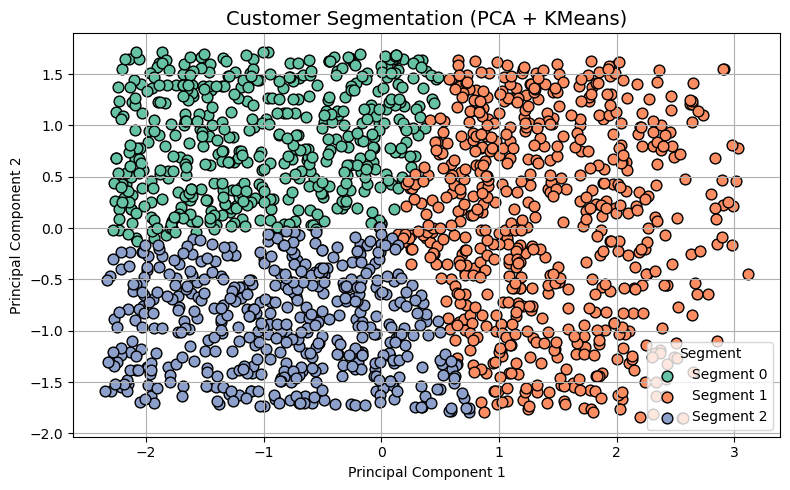

In [784]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Select features
seg_features = ['Customer_Lifetime_Value', 'Loyalty_Score', 'Purchase_Amount']
X_seg = df[seg_features].dropna()

# Scale
scaler_seg = StandardScaler()
X_seg_scaled = scaler_seg.fit_transform(X_seg)

# KMeans clustering
kmeans_model = KMeans(n_clusters=3, random_state=42)
df.loc[X_seg.index, 'Segment'] = kmeans_model.fit_predict(X_seg_scaled)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_seg_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Segment'] = df.loc[X_seg.index, 'Segment'].values

# Use seaborn color palette
palette = sns.color_palette("Set2", n_colors=3)

# Plot
plt.figure(figsize=(8, 5))
for segment in sorted(df_pca['Segment'].unique()):
    subset = df_pca[df_pca['Segment'] == segment]
    plt.scatter(subset['PC1'], subset['PC2'],
                label=f"Segment {int(segment)}",  # cast to int for label
                color=palette[int(segment)],      # ✅ cast to int to fix the error
                s=60, edgecolors='k')

plt.title("Customer Segmentation (PCA + KMeans)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Segment")
plt.grid(True)
plt.tight_layout()
plt.show()


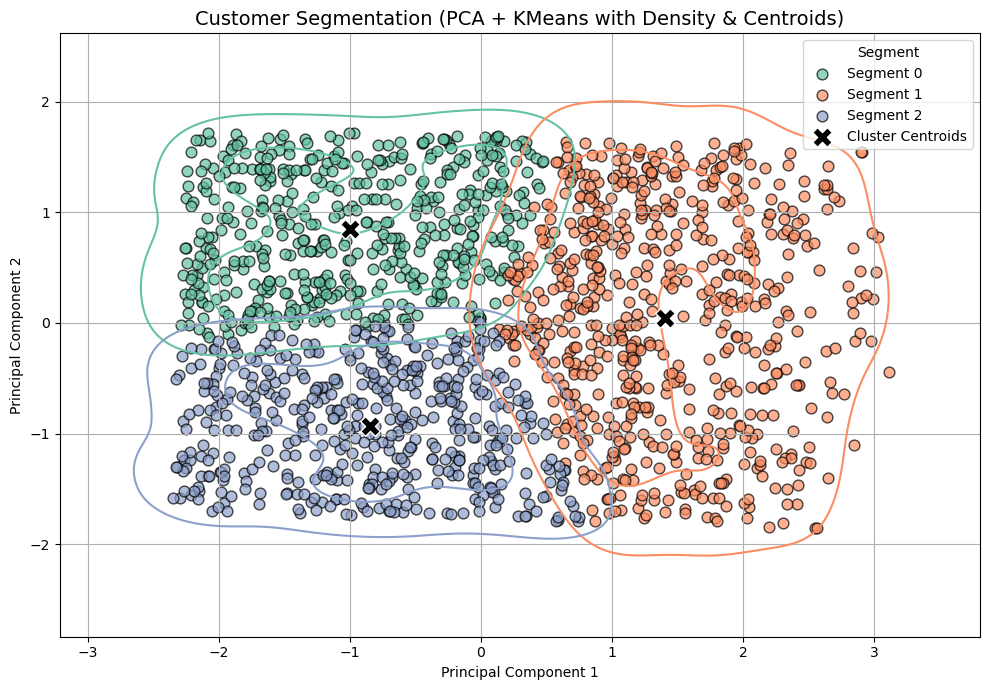

In [785]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler # Added: Import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Added: Import numpy for potential numerical operations

# Select features for segmentation
# Based on your latest debug output for amazon0.ipynb, 'Loyalty_Score' and 'CLV' (not suffixed) are present.
# If you want to include CLV in segmentation, add it here.
seg_features = ['Customer_Lifetime_Value', 'Loyalty_Score', 'Purchase_Amount'] # Using 'Loyalty_Score' as per your debug output
# Example if you also want to include CLV: seg_features = ['Age', 'Rating', 'Loyalty_Score', 'CLV']

# Prepare data for segmentation: drop NaNs and create a copy to avoid SettingWithCopyWarning
df_seg_model_ready = df[seg_features].dropna().copy()

# Scale features
scaler_seg = StandardScaler()
X_seg_scaled = scaler_seg.fit_transform(df_seg_model_ready[seg_features]) # Fit and transform on the ready data

# KMeans clustering
# Added n_init parameter for compatibility with newer scikit-learn versions
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init='auto') # Recommended to set n_init explicitly
df.loc[df_seg_model_ready.index, 'Segment'] = kmeans_model.fit_predict(X_seg_scaled) # Assign segment back to original df using index

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_seg_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
# Ensure 'Segment' column aligns with PCA results using the same index
df_pca['Segment'] = df.loc[df_seg_model_ready.index, 'Segment'].values


# Use seaborn color palette
palette = sns.color_palette("Set2", n_colors=3)

# Plot
plt.figure(figsize=(10, 7)) # Increased figure size for better visibility
for segment in sorted(df_pca['Segment'].unique()):
    subset = df_pca[df_pca['Segment'] == segment]
    plt.scatter(subset['PC1'], subset['PC2'],
                label=f"Segment {int(segment)}",
                color=palette[int(segment)],
                s=60, edgecolors='k', alpha=0.7) # Added alpha for better visibility with KDE

    # Add KDE contours for each segment
    sns.kdeplot(x=subset['PC1'], y=subset['PC2'],
                color=palette[int(segment)],
                levels=3, linewidths=1.5, ax=plt.gca()) # Plot KDE on current axes

# Plot cluster centroids
# Calculate centroids in the PCA space
# Need to map scaled centroids back to PCA space
scaled_centroids = kmeans_model.cluster_centers_
pca_centroids = pca.transform(scaled_centroids)

plt.scatter(pca_centroids[:, 0], pca_centroids[:, 1],
            marker='X', s=200, color='black', edgecolor='white', linewidth=1,
            label='Cluster Centroids', zorder=10) # Centroids on top

plt.title("Customer Segmentation (PCA + KMeans with Density & Centroids)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Segment")
plt.grid(True)
plt.tight_layout()
plt.show()


In [786]:
# Add these lines to check class balance
print("\nDistribution of Synthetic Churn in DataFrame:")
print(df['Churn'].value_counts())
print("\nDistribution of Synthetic Churn in Test Set (y_test_churn):")
print(y_test_churn.value_counts())  # ✅ matches what cell 13 defines


Distribution of Synthetic Churn in DataFrame:
Churn
1    797
0    794
Name: count, dtype: int64

Distribution of Synthetic Churn in Test Set (y_test_churn):
Churn
1    160
0    159
Name: count, dtype: int64


In [787]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import joblib

# Step 0: Encode any remaining string columns that CLV features need
le = LabelEncoder()
for col in ['Payment_Method', 'Gender', 'Return_Status', 'Customer_Segment']:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

# CLV features — 9 features, Discount_Applied excluded (zero variance)
clv_features = ['Age', 'Purchase_Amount', 'Payment_Method', 'Loyalty_Score',
                 'Rating', 'Gender', 'Return_Status', 'Customer_Segment',
                 'Days_Since_Purchase']

# Step 1: Keep only rows where all features + target are present
df_clv_model_ready = df.dropna(subset=clv_features + ['Customer_Lifetime_Value']).copy()

if df_clv_model_ready.empty or len(df_clv_model_ready) < 10:
    print("❌ Not enough valid data. Skipping CLV model training.")
else:
    # Step 2: Features and target
    X_clv = df_clv_model_ready[clv_features].copy()
    y_clv = df_clv_model_ready['Customer_Lifetime_Value']

    # Fill any remaining NaNs in features with median
    X_clv = X_clv.fillna(X_clv.median(numeric_only=True))

    # Step 3: Train-test split
    X_clv_train, X_clv_test, y_clv_train, y_clv_test = train_test_split(
        X_clv, y_clv, test_size=0.2, random_state=42
    )

    # Step 4: Scale
    scaler_clv = StandardScaler()
    X_clv_train_scaled = scaler_clv.fit_transform(X_clv_train)
    X_clv_test_scaled  = scaler_clv.transform(X_clv_test)

    # Step 5: Train
    clv_model = LinearRegression()
    clv_model.fit(X_clv_train_scaled, y_clv_train)

    # Save
    joblib.dump(clv_model,  'clv_model.pkl')
    joblib.dump(scaler_clv, 'clv_scaler.pkl')
    print("✅ CLV model and scaler saved.")

    # Step 6: Predict
    y_pred_clv = clv_model.predict(X_clv_test_scaled)

    # Step 7: Evaluate
    non_zero_mask = y_clv_test != 0
    mape = np.mean(np.abs(
        (y_clv_test[non_zero_mask] - y_pred_clv[non_zero_mask]) / y_clv_test[non_zero_mask]
    )) * 100

    print("\n📈 [CLV Regression Results]")
    print(f"R² Score : {r2_score(y_clv_test, y_pred_clv):.4f}")
    print(f"MSE      : {mean_squared_error(y_clv_test, y_pred_clv):.2f}")
    print(f"MAE      : {mean_absolute_error(y_clv_test, y_pred_clv):.2f}")
    print(f"MAPE     : {mape:.2f}%")
    print(f"Features : {clv_features}")

✅ CLV model and scaler saved.

📈 [CLV Regression Results]
R² Score : 0.7648
MSE      : 644373.59
MAE      : 594.58
MAPE     : 27.80%
Features : ['Age', 'Purchase_Amount', 'Payment_Method', 'Loyalty_Score', 'Rating', 'Gender', 'Return_Status', 'Customer_Segment', 'Days_Since_Purchase']


Using churn features: ['Age', 'Purchase_Amount', 'Payment_Method', 'Loyalty_Score', 'Avg_Purchase_Value', 'Days_Since_Purchase', 'Rating', 'Location', 'Product_Category', 'Return_Status', 'Customer_Segment']
🔢 Predicted class counts: [161 158]


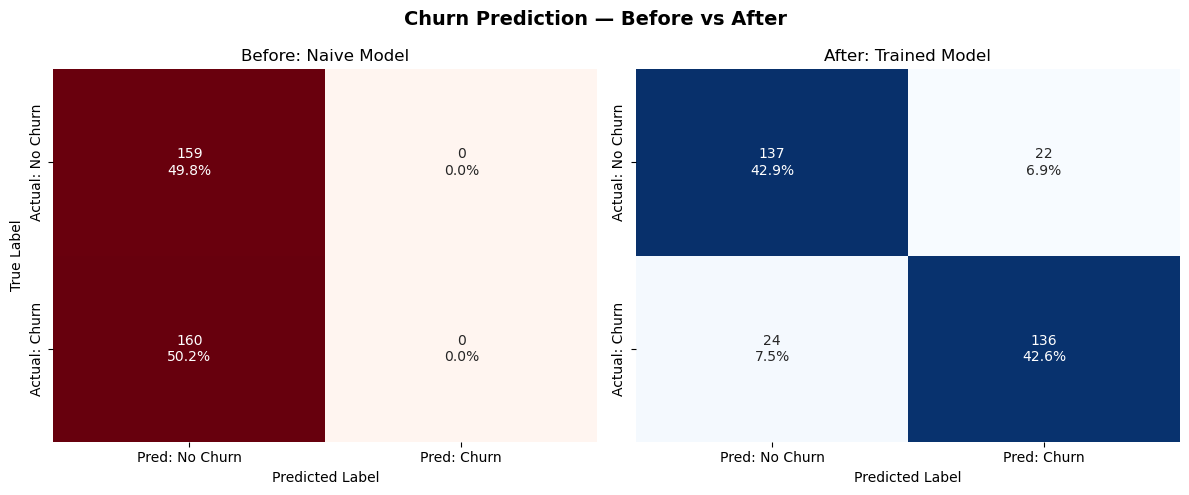


📊 Churn Accuracy: 85.58%
              precision    recall  f1-score   support

    No Churn       0.85      0.86      0.86       159
       Churn       0.86      0.85      0.86       160

    accuracy                           0.86       319
   macro avg       0.86      0.86      0.86       319
weighted avg       0.86      0.86      0.86       319



In [788]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 0: Encode any remaining string columns needed for churn features
le = LabelEncoder()
for col in ['Payment_Method', 'Gender', 'Return_Status', 'Customer_Segment',
            'Location', 'Product_Category', 'Preferred_Shopping_Channel']:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

# Churn features — expanded, Discount_Applied excluded (zero variance)
churn_features = ['Age', 'Purchase_Amount', 'Payment_Method', 'Loyalty_Score',
                  'CLV_Engineered', 'Avg_Purchase_Value', 'Days_Since_Purchase',
                  'Rating', 'Location', 'Product_Category', 'Return_Status',
                  'Customer_Segment']

# Only keep features that actually exist in df
churn_features = [f for f in churn_features if f in df.columns]
print(f"Using churn features: {churn_features}")

# Build model-ready dataframe
df_churn = df[churn_features + ['Churn']].dropna().copy()
df_churn[churn_features] = df_churn[churn_features].fillna(
    df_churn[churn_features].median(numeric_only=True)
)

X_c = df_churn[churn_features]
y_c = df_churn['Churn']

# Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
)

# Scale
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled  = scaler_c.transform(X_test_c)

# Train Logistic Regression with balanced class weights
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(X_train_c_scaled, y_train_c)

# Predict
y_pred_c = log_model.predict(X_test_c_scaled)
print("🔢 Predicted class counts:", np.bincount(y_pred_c.astype(int)))

# Confusion matrices
cm_after  = confusion_matrix(y_test_c, y_pred_c)
cm_before = confusion_matrix(y_test_c, np.zeros_like(y_test_c))  # naive baseline

def make_labels(cm):
    cm_perc = cm / cm.sum() * 100
    return np.array([
        [f"{cm[0,0]}\n{cm_perc[0,0]:.1f}%", f"{cm[0,1]}\n{cm_perc[0,1]:.1f}%"],
        [f"{cm[1,0]}\n{cm_perc[1,0]:.1f}%", f"{cm[1,1]}\n{cm_perc[1,1]:.1f}%"]
    ])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_before, annot=make_labels(cm_before), fmt='', cmap='Reds',
            cbar=False,
            xticklabels=['Pred: No Churn', 'Pred: Churn'],
            yticklabels=['Actual: No Churn', 'Actual: Churn'], ax=axes[0])
axes[0].set_title("Before: Naive Model")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_after, annot=make_labels(cm_after), fmt='', cmap='Blues',
            cbar=False,
            xticklabels=['Pred: No Churn', 'Pred: Churn'],
            yticklabels=['Actual: No Churn', 'Actual: Churn'], ax=axes[1])
axes[1].set_title("After: Trained Model")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("")

plt.suptitle("Churn Prediction — Before vs After", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Churn Accuracy: {accuracy_score(y_test_c, y_pred_c):.2%}")
print(classification_report(y_test_c, y_pred_c, target_names=['No Churn', 'Churn']))

In [789]:
print("🔢 Predicted class counts:", np.bincount(y_pred_c))


🔢 Predicted class counts: [161 158]


In [790]:
from sklearn.metrics import r2_score
print("CLV R² Score:", r2_score(y_clv_test, y_pred_clv))


CLV R² Score: 0.7648463637872036


Min CLV (actual): 73.39072107154377
Max CLV (actual): 6843.355252573721
Min CLV (predicted): 91.27793154514757
Max CLV (predicted): 5030.719074545932


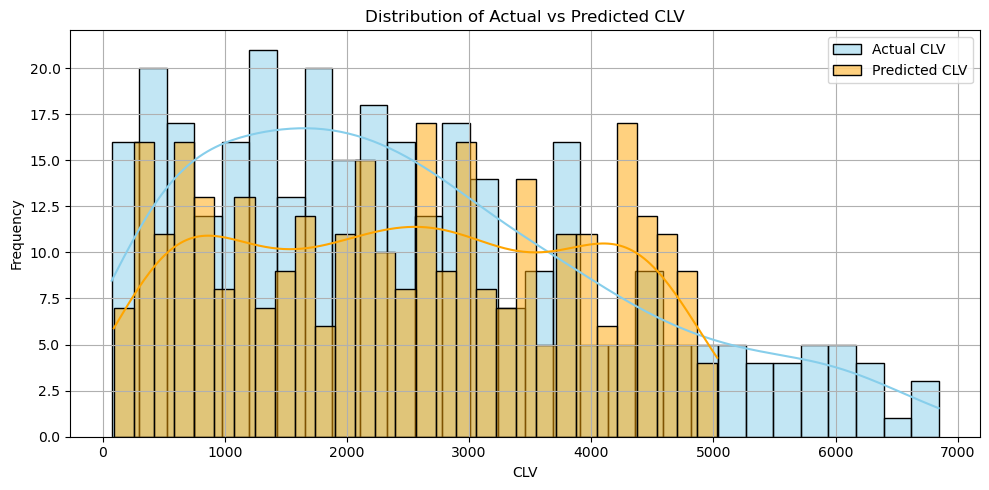

In [791]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Basic stats
print("Min CLV (actual):", y_clv_test.min())
print("Max CLV (actual):", y_clv_test.max())
print("Min CLV (predicted):", y_pred_clv.min())
print("Max CLV (predicted):", y_pred_clv.max())

# Histogram of actual vs predicted CLV
plt.figure(figsize=(10, 5))

sns.histplot(y_clv_test, color='skyblue', label='Actual CLV', kde=True, bins=30)
sns.histplot(y_pred_clv, color='orange', label='Predicted CLV', kde=True, bins=30)

plt.title("Distribution of Actual vs Predicted CLV")
plt.xlabel("CLV")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


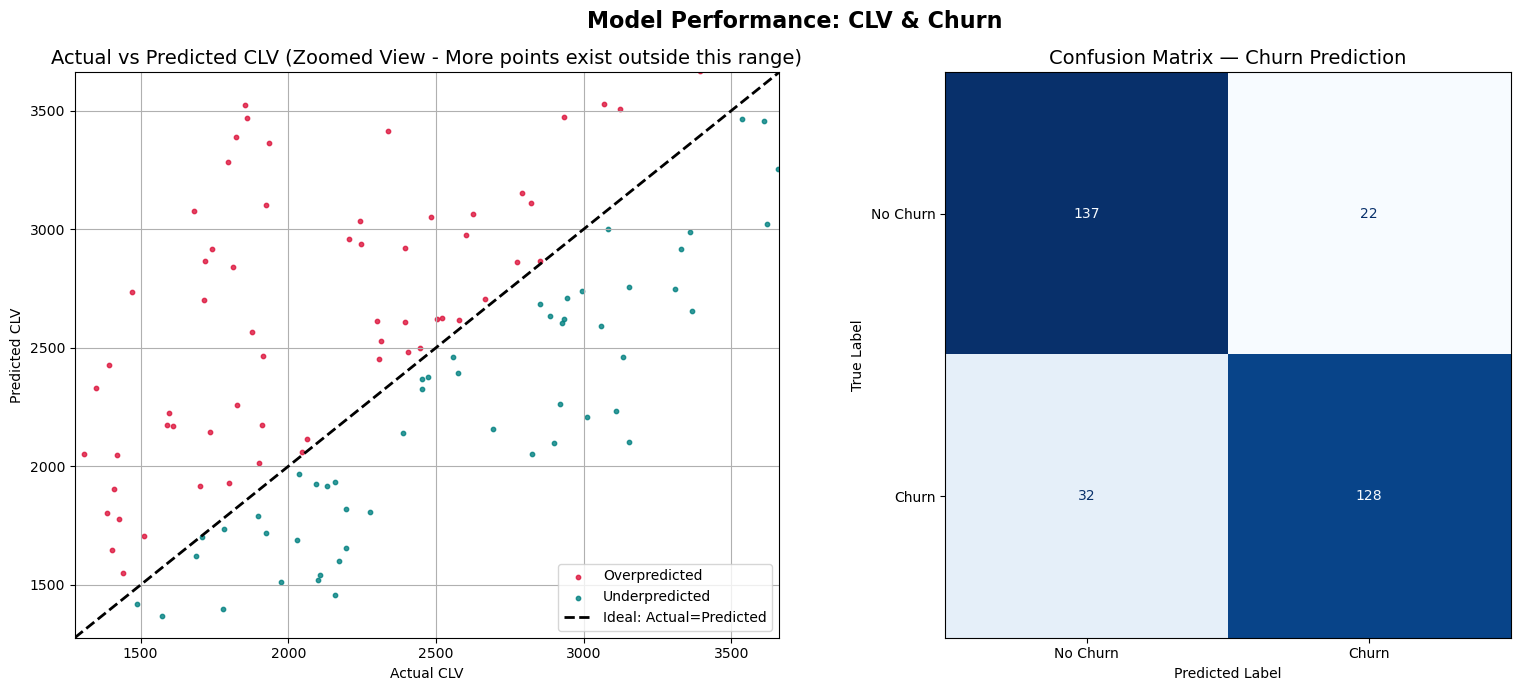

In [792]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay # Only import what's needed for the plot
from matplotlib.ticker import MultipleLocator, AutoLocator # Import AutoLocator for flexible tick intervals

# --- ✅ Convert to NumPy for CLV residual logic (if not already numpy arrays) ---
# Ensure these variables come from your CLV prediction block
y_clv_test_np = np.array(y_clv_test)
y_pred_clv_np = np.array(y_pred_clv)

residuals = y_pred_clv_np - y_clv_test_np
over_idx = residuals >= 0 # Indices where model overpredicted (predicted >= actual)
under_idx = residuals < 0  # Indices where model underpredicted (predicted < actual)

# --- ✅ Combined Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7)) # Increased width for better separation

# --- ✅ Left Plot: CLV Regression Error (Actual vs Predicted)
# Calculate robust min/max for plot limits using even tighter percentiles to zoom in further
# This focuses on an even denser part of the data, making points more discernible.
lower_bound = np.percentile(np.concatenate([y_clv_test_np, y_pred_clv_np]), 30) # Changed to 30th percentile for more zoom
upper_bound = np.percentile(np.concatenate([y_clv_test_np, y_pred_clv_np]), 70) # Changed to 70th percentile for more zoom

# Add a small buffer to the bounds
plot_min_clv = max(0, lower_bound * 0.9) # Ensure it doesn't go below zero
plot_max_clv = upper_bound * 1.1 # Add a small buffer to the upper bound

# Ensure a minimum range if the data is extremely clustered at low values
if plot_max_clv - plot_min_clv < 150: # If the range is too small, extend it
    plot_max_clv = plot_min_clv + 150 # Ensure at least a 150 unit range


# Add a small random jitter to x and y coordinates to help separate overlapping points
# Jitter amount is now based on the *new* plot range, and made slightly smaller
jitter_amount = (plot_max_clv - plot_min_clv) * 0.003 # Adjusted jitter amount for better separation

axes[0].scatter(y_clv_test_np[over_idx] + np.random.uniform(-jitter_amount, jitter_amount, len(y_clv_test_np[over_idx])),
                y_pred_clv_np[over_idx] + np.random.uniform(-jitter_amount, jitter_amount, len(y_pred_clv_np[over_idx])),
                color='crimson', alpha=0.8, label='Overpredicted', s=10) # Increased alpha, smaller marker size

axes[0].scatter(y_clv_test_np[under_idx] + np.random.uniform(-jitter_amount, jitter_amount, len(y_clv_test_np[under_idx])),
                y_pred_clv_np[under_idx] + np.random.uniform(-jitter_amount, jitter_amount, len(y_pred_clv_np[under_idx])),
                color='teal', alpha=0.8, label='Underpredicted', s=10) # Increased alpha, smaller marker size


# Plot the ideal line where Actual = Predicted
axes[0].plot([plot_min_clv, plot_max_clv], # Use the calculated dynamic limits for the line
             [plot_min_clv, plot_max_clv],
             'k--', lw=2, label='Ideal: Actual=Predicted')

# Set x and y axis limits based on the calculated dynamic limits
axes[0].set_xlim(plot_min_clv, plot_max_clv)
axes[0].set_ylim(plot_min_clv, plot_max_clv)

# Updated title to indicate zooming and presence of more points
axes[0].set_title("Actual vs Predicted CLV (Zoomed View - More points exist outside this range)", fontsize=14)
axes[0].set_xlabel("Actual CLV")
axes[0].set_ylabel("Predicted CLV")

# Set major tick locators for a "40 40 gap" (will adjust based on new range)
axes[0].xaxis.set_major_locator(AutoLocator()) # Keep AutoLocator for flexibility
axes[0].yaxis.set_major_locator(AutoLocator())


axes[0].grid(True) # Ensure grid is visible
axes[0].legend()


# --- ✅ Right Plot: Confusion Matrix (Manual Placement to Avoid Overlap)
# Ensure cm_churn is defined from your churn prediction block
disp_churn = ConfusionMatrixDisplay(confusion_matrix=cm_churn, display_labels=["No Churn", "Churn"])
disp_churn.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title("Confusion Matrix — Churn Prediction", fontsize=14)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

# --- ✅ Title & Layout
plt.suptitle("Model Performance: CLV & Churn", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [793]:
accuracy = 100 - mape
print(f"🎯 Approximate Prediction Accuracy: {accuracy:.2f}%")


🎯 Approximate Prediction Accuracy: 72.20%


In [794]:
print(f"CLV range: {df['CLV'].min():.2f} to {df['CLV'].max():.2f}")

CLV range: 10.08 to 1217.56


In [795]:
print("clv_model defined:", 'clv_model' in locals())
print("scaler_clv defined:", 'scaler_clv' in locals())
print("churn_model defined:", 'churn_model' in locals())
print("scaler_churn defined:", 'scaler_churn' in locals())
print("kmeans_model defined:", 'kmeans_model' in locals())
print("scaler_seg defined:", 'scaler_seg' in locals())

clv_model defined: True
scaler_clv defined: True
churn_model defined: True
scaler_churn defined: True
kmeans_model defined: True
scaler_seg defined: True


In [796]:
import joblib
import os

# --- Save CLV model and scaler ---
clv_model_filename = 'clv_model.pkl'
scaler_clv_filename = 'clv_scaler.pkl'

joblib.dump(clv_model, clv_model_filename)
joblib.dump(scaler_clv, scaler_clv_filename)

clv_model_abs_path = os.path.abspath(clv_model_filename)
scaler_clv_abs_path = os.path.abspath(scaler_clv_filename)
print(f"✅ CLV model saved to: {clv_model_abs_path}")
print(f"✅ CLV scaler saved to: {scaler_clv_abs_path}")

# --- Save Churn model and scaler ---
churn_model_filename = 'churn_model.pkl'
scaler_churn_filename = 'churn_scaler.pkl'      # ← fixed from 'scaler_churn.pkl'

joblib.dump(churn_model, churn_model_filename)
joblib.dump(scaler_churn, scaler_churn_filename)

churn_model_abs_path = os.path.abspath(churn_model_filename)
scaler_churn_abs_path = os.path.abspath(scaler_churn_filename)
print(f"✅ Churn model saved to: {churn_model_abs_path}")
print(f"✅ Churn scaler saved to: {scaler_churn_abs_path}")

# --- Save KMeans model and scaler ---
kmeans_model_filename = 'kmeans_model.pkl'
scaler_kmeans_filename = 'kmeans_scaler.pkl'

joblib.dump(kmeans_model, kmeans_model_filename)
joblib.dump(scaler_seg, scaler_kmeans_filename)

kmeans_model_abs_path = os.path.abspath(kmeans_model_filename)
scaler_kmeans_abs_path = os.path.abspath(scaler_kmeans_filename)
print(f"✅ KMeans model saved to: {kmeans_model_abs_path}")
print(f"✅ KMeans scaler saved to: {scaler_kmeans_abs_path}")

✅ CLV model saved to: /Users/rajeshkumarswain/Downloads/appy 2/clv_model.pkl
✅ CLV scaler saved to: /Users/rajeshkumarswain/Downloads/appy 2/clv_scaler.pkl
✅ Churn model saved to: /Users/rajeshkumarswain/Downloads/appy 2/churn_model.pkl
✅ Churn scaler saved to: /Users/rajeshkumarswain/Downloads/appy 2/churn_scaler.pkl
✅ KMeans model saved to: /Users/rajeshkumarswain/Downloads/appy 2/kmeans_model.pkl
✅ KMeans scaler saved to: /Users/rajeshkumarswain/Downloads/appy 2/kmeans_scaler.pkl


In [797]:
print(f"Loyalty_Score range: {df['Loyalty_Score'].min():.2f} to {df['Loyalty_Score'].max():.2f}")

Loyalty_Score range: 1.00 to 100.00


In [798]:
# One-time cleanup — consolidate CLV_x/CLV_y → CLV and fix all _x/_y duplicates
import pandas as pd

# Fix CLV
if 'CLV' not in df.columns:
    if 'CLV_x' in df.columns:
        df.rename(columns={'CLV_x': 'CLV'}, inplace=True)
        print("✅ Renamed CLV_x → CLV")
    if 'CLV_y' in df.columns:
        df.drop(columns=['CLV_y'], inplace=True)
        print("✅ Dropped CLV_y")

# Fix Loyalty_Score duplicates
if 'Loyalty_Score_x' in df.columns:
    df.drop(columns=['Loyalty_Score_x'], inplace=True)
    print("✅ Dropped Loyalty_Score_x (Loyalty_Score_y is the correct one)")

# Fix Purchase_Frequency, Avg_Purchase_Value, Days_Since_Purchase duplicates
for col in ['Purchase_Frequency', 'Avg_Purchase_Value', 'Days_Since_Purchase']:
    if f'{col}_x' in df.columns:
        df.rename(columns={f'{col}_x': col}, inplace=True)
        print(f"✅ Renamed {col}_x → {col}")
    if f'{col}_y' in df.columns:
        df.drop(columns=[f'{col}_y'], inplace=True)
        print(f"✅ Dropped {col}_y")

print("\nCurrent columns:", df.columns.tolist())


Current columns: ['Customer_ID', 'Customer_Name', 'Age', 'Gender', 'Location', 'Product_Category', 'Product_ID', 'Purchase_Date', 'Purchase_Amount', 'Payment_Method', 'Rating', 'Feedback_Comments', 'Customer_Lifetime_Value', 'Loyalty_Score', 'Discount_Applied', 'Return_Status', 'Customer_Segment', 'Preferred_Shopping_Channel', 'Churn', 'CLV', 'Purchase_Frequency', 'Avg_Purchase_Value', 'Days_Since_Purchase', 'Segment']


In [799]:
print(f"CLV range: {df['CLV'].min():.2f} to {df['CLV'].max():.2f}")

CLV range: 10.08 to 1217.56


In [800]:
# Never overwrite the source file — save to a separate output
df.to_excel("amazonnew_output.xlsx", index=False)
print("✅ Output saved to amazonnew_output.xlsx")


✅ Output saved to amazonnew_output.xlsx


In [801]:
# Export cleaned and engineered DataFrame to CSV
df.to_csv('amazon_cleaned.csv', index=False)
print(f"✅ CSV saved: amazon_cleaned.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

✅ CSV saved: amazon_cleaned.csv
Shape: (1591, 24)
Columns: ['Customer_ID', 'Customer_Name', 'Age', 'Gender', 'Location', 'Product_Category', 'Product_ID', 'Purchase_Date', 'Purchase_Amount', 'Payment_Method', 'Rating', 'Feedback_Comments', 'Customer_Lifetime_Value', 'Loyalty_Score', 'Discount_Applied', 'Return_Status', 'Customer_Segment', 'Preferred_Shopping_Channel', 'Churn', 'CLV', 'Purchase_Frequency', 'Avg_Purchase_Value', 'Days_Since_Purchase', 'Segment']
